In [2]:
!pip install shap

  Using cached numba-0.60.0-cp39-cp39-win_amd64.whl.metadata (2.8 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached llvmlite-0.43.0-cp39-cp39-win_amd64.whl.metadata (4.9 kB)
   ---------------------------------------- 0.0/547.2 kB ? eta -:--:--
   ------------------- -------------------- 262.1/547.2 kB ? eta -:--:--
   ---------------------------------------- 547.2/547.2 kB 2.0 MB/s  0:00:00
Using cached numba-0.60.0-cp39-cp39-win_amd64.whl (2.7 MB)
Using cached llvmlite-0.43.0-cp39-cp39-win_amd64.whl (28.1 MB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)

   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- -----------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import shap
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("loans.csv")
df.head()

,customer.id,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,10001,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854.0,52.1,0.0,0,0,0
1,10002,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623.0,76.7,0.0,0,0,0
2,10003,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511.0,25.6,1.0,0,0,0
3,10004,1,debt_consolidation,0.1008,162.34,11.350407,8.1,712,2699.958333,33667.0,73.2,1.0,0,0,0
4,10005,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740.0,39.5,0.0,1,0,0


In [16]:
# Replace 'zero' string with 0
df.replace('zero', 0, inplace=True)

In [17]:
df.head()

,customer.id,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,10001,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854.0,52.1,0.0,0,0,0
1,10002,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623.0,76.7,0.0,0,0,0
2,10003,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511.0,25.6,1.0,0,0,0
3,10004,1,debt_consolidation,0.1008,162.34,11.350407,8.1,712,2699.958333,33667.0,73.2,1.0,0,0,0
4,10005,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740.0,39.5,0.0,1,0,0


In [18]:
# Convert all columns to numeric where possible
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

In [19]:
# One-hot encoding for categorical column
df = pd.get_dummies(df, columns=['purpose'], drop_first=True)

In [20]:
# Convert remaining to numeric (after encoding)
df = df.apply(pd.to_numeric, errors='coerce')

In [21]:
# Drop rows with invalid values
df = df.dropna()

In [34]:
df.head()

,customer.id,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,10001,1.0,0.1189,829.10,11.350407,19.48,737,5639.958333,28854.0,52.1,0.0,0.0,0.0,0,0,1,0,0,0,0
1,10002,1.0,0.1071,228.22,11.082143,14.29,707,2760.000000,33623.0,76.7,0.0,0.0,0.0,0,1,0,0,0,0,0
2,10003,1.0,0.1357,366.86,10.373491,11.63,682,4710.000000,3511.0,25.6,1.0,0.0,0.0,0,0,1,0,0,0,0
3,10004,1.0,0.1008,162.34,11.350407,8.10,712,2699.958333,33667.0,73.2,1.0,0.0,0.0,0,0,1,0,0,0,0
4,10005,1.0,0.1426,102.92,11.299732,14.97,667,4066.000000,4740.0,39.5,0.0,1.0,0.0,0,1,0,0,0,0,0


In [22]:
X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [25]:
print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", pd.Series(y_train_sm).value_counts())

Before SMOTE:
 0    6393
1    1214
Name: not.fully.paid, dtype: int64
After SMOTE:
 0    6393
1    6393
Name: not.fully.paid, dtype: int64


In [26]:
scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

In [27]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train_sm, y_train_sm)
rf.fit(X_train_sm, y_train_sm)

RandomForestClassifier(random_state=42)

In [28]:
for name, model in {'Logistic Regression': lr, 'Random Forest': rf}.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.74      0.80      1598
           1       0.24      0.42      0.30       304

    accuracy                           0.69      1902
   macro avg       0.55      0.58      0.55      1902
weighted avg       0.77      0.69      0.72      1902

ROC-AUC: 0.635623888413148

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      1598
           1       0.30      0.16      0.21       304

    accuracy                           0.81      1902
   macro avg       0.58      0.54      0.55      1902
weighted avg       0.77      0.81      0.78      1902

ROC-AUC: 0.678920196298004


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.690852   0.236059  0.417763  0.301663
1        Random Forest  0.807045   0.301887  0.157895  0.207343


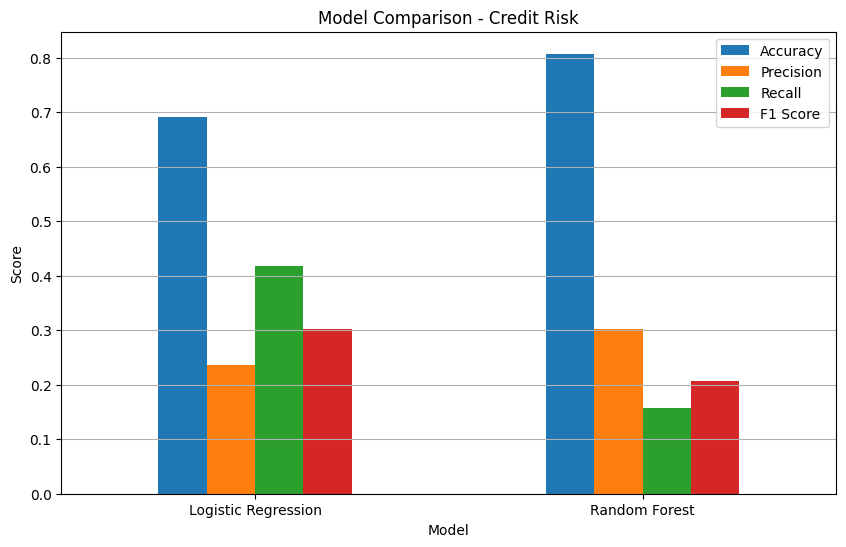

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

results = []

models = {
    "Logistic Regression": lr,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

print(results_df)

# ===============================
# Plot
# ===============================
results_df.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Comparison - Credit Risk")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

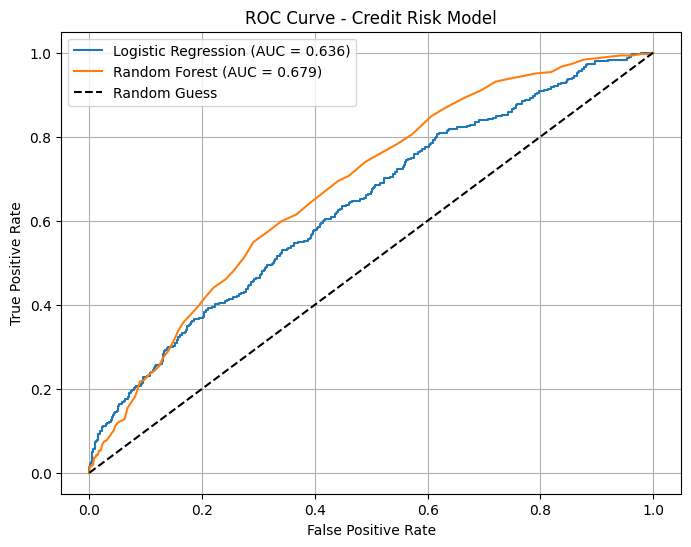

In [32]:
from sklearn.metrics import roc_curve, auc

# ROC Curve Plot

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": lr,
    "Random Forest": rf
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# Random guess line
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Risk Model")
plt.legend()
plt.grid()

plt.show()

In [29]:
#  SHAP Explainability
explainer = shap.Explainer(rf, X_train_sm)
shap_values = explainer(X_test_scaled[:100])

 98%|===================| 195/200 [00:24<00:00]        

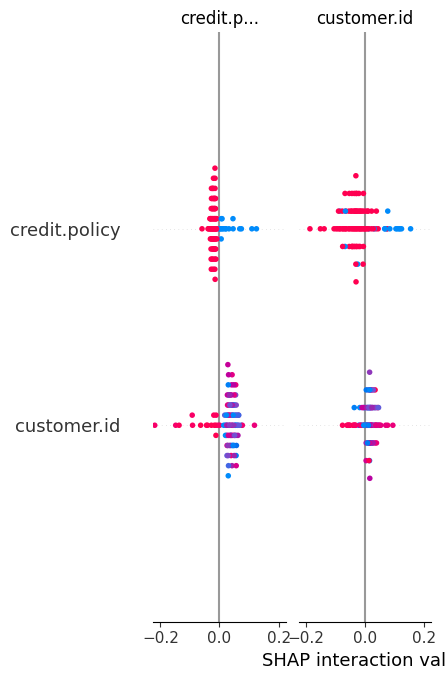

In [30]:
# Summary Plot
shap.summary_plot(shap_values, X_test.iloc[:100])

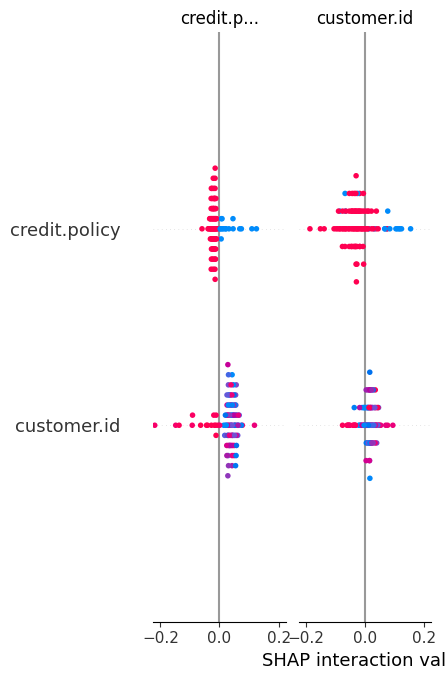

In [31]:
# Summary Plot
shap.summary_plot(shap_values, X_test.iloc[:100])